# P7demo

## Importation des librairies

In [1]:
import numpy as np
import pandas as pd # openpyxl required to read Excel files
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des onglets du fichier Excel

In [2]:
excel_filename = "data/sanitoral.xlsx"

Plusieurs points de vigilance

- Le nombre de lignes avant les entêtes (headers) varie d'un onglet à l'autre.
- Les colonnes avec les identifiants des projets portent des noms différents (toutes renommées `Project ID`).

In [3]:
df_country_profile = pd.read_excel(excel_filename, sheet_name="Country_Profiles", header=1)
df_country_profile.head()

,Country,Region,Type
0,France,Western Europe,Affiliate
1,Belgique,Western Europe,Affiliate
2,Hollande,Western Europe,Affiliate
3,Luxembourg,Western Europe,Affiliate
4,Italie,Western Europe,Affiliate


In [4]:
df_project_location = pd.read_excel(excel_filename, sheet_name="Projects_Locations", header=1)
df_project_location.head()

,Project ID,Country
0,1,Equateur
1,2,France
2,3,Liban
3,4,Egypte
4,5,Afrique du Sud


In [5]:
df_project_type = pd.read_excel(excel_filename, sheet_name="Project type", header=3)
df_project_type.head()

,Project ID,Project Type
0,1,Marketing - Launch of new product
1,2,Marketing - Launch of new product
2,3,Marketing - Launch of new product
3,4,Marketing - Launch of new product
4,5,Marketing - Launch of new product


In [6]:
df_planned = pd.read_excel(excel_filename, sheet_name="Projects_plans", header=2)
df_planned.rename(columns={"Planned_Delivrable":"Planned_Deliverables"}, inplace=True)
df_planned.head()

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Deliverables
0,1,Phase 1 - Planning,2018-01-16,196,50000,10
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23
4,2,Phase 1 - Planning,2018-01-30,16,100000,6


In [7]:
df_actual_cost = pd.read_excel(excel_filename, sheet_name="Actual_Costs", header=3)
df_actual_cost.rename(columns={"Proj_ID":"Project ID"}, inplace=True)
df_actual_cost.head()

,Project ID,Phase,Actual_Cost
0,1,Phase 1 - Planning,59600
1,2,Phase 1 - Planning,86700
2,3,Phase 1 - Planning,65800
3,4,Phase 1 - Planning,65100
4,5,Phase 1 - Planning,52600


In [8]:
df_actual_duration = pd.read_excel(excel_filename, sheet_name="Actual_Duration", header=5)
df_actual_duration.rename(columns={"Project":"Project ID"}, inplace=True)
df_actual_duration.head()

,Project ID,Phase,Actual_Duration
0,1,Phase 1 - Planning,196
1,1,Phase 2 - Initiation,7
2,1,Phase 3 - Implementation,176
3,1,Phase 4 - Manufacturing,64
4,2,Phase 1 - Planning,16


In [9]:
df_actual_deliverable = pd.read_excel(excel_filename, sheet_name="Actual_Delivrable", header=3)
df_actual_deliverable.rename(columns={"ID":"Project ID"}, inplace=True)
df_actual_deliverable.head()

,Project ID,Phase,Actual_Deliverables
0,1,Phase 1 - Planning,10
1,1,Phase 2 - Initiation,16
2,1,Phase 3 - Implementation,25
3,1,Phase 4 - Manufacturing,23
4,2,Phase 1 - Planning,6


## Analyse exploratoire

In [10]:
df_country_profile.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Country  52 non-null     str  
 1   Region   52 non-null     str  
 2   Type     52 non-null     str  
dtypes: str(3)
memory usage: 1.3 KB


In [11]:
df_project_location.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Project ID  104 non-null    int64
 1   Country     104 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [12]:
df_project_type.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Project ID    104 non-null    int64
 1   Project Type  104 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [13]:
df_planned.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Project ID            520 non-null    int64         
 1   Phase                 520 non-null    str           
 2   Start Date            520 non-null    datetime64[us]
 3   Planned_Duration      520 non-null    int64         
 4   Planned_Cost          520 non-null    int64         
 5   Planned_Deliverables  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 24.5 KB


In [14]:
df_actual_duration.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Project ID       520 non-null    int64
 1   Phase            520 non-null    str  
 2   Actual_Duration  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [15]:
df_actual_cost.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Project ID   520 non-null    int64
 1   Phase        520 non-null    str  
 2   Actual_Cost  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [16]:
df_actual_deliverable.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Project ID           520 non-null    int64
 1   Phase                520 non-null    str  
 2   Actual_Deliverables  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


## Jointure

In [17]:
df_merge = pd.merge(df_country_profile, df_project_location)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Country     104 non-null    str  
 1   Region      104 non-null    str  
 2   Type        104 non-null    str  
 3   Project ID  104 non-null    int64
dtypes: int64(1), str(3)
memory usage: 3.4 KB


In [18]:
df_merge = pd.merge(df_merge, df_project_type)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country       104 non-null    str  
 1   Region        104 non-null    str  
 2   Type          104 non-null    str  
 3   Project ID    104 non-null    int64
 4   Project Type  104 non-null    str  
dtypes: int64(1), str(4)
memory usage: 4.2 KB


In [19]:
df_merge = pd.merge(df_merge, df_planned)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(5)
memory usage: 40.8 KB


In [20]:
df_merge = pd.merge(df_merge, df_actual_duration)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 44.8 KB


In [21]:
df_merge = pd.merge(df_merge, df_actual_cost)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
 11  Actual_Cost           520 non-null    int64         
dtypes: datetime64[us](1), int64(6), str(5)
memory usage: 48.9 KB


In [22]:
df_merge = pd.merge(df_merge, df_actual_deliverable)
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
 11  Actual_Cost           520 non-null    int64         
 12  Actual_Deliverables   520 non-null    int64         
dtypes: datetime64[us](1), int64(7),

In [23]:
for project_type in sorted(pd.unique(df_merge["Project Type"])):
    df_tmp = df_merge[ (df_merge["Project Type"] == project_type) ]
    n = df_tmp.shape[0]
    print(*sorted(pd.unique(df_tmp["Phase"])), sep="\n")
    df_tmp = df_tmp[["Project ID","Phase"]].groupby("Project ID").agg({ "Phase": [ "count", "nunique" ] })
    # reshape() : 1 seul argument pour passer d'une matrice (2D) à un vecteur (1D)
    # -1 signifie "calcul automatique de la taille du vecteur" (nb lignes × nb colonnes)
    a = pd.unique(df_tmp.to_numpy().reshape(-1))
    assert len(a) == 1
    m = a[0]
    print(f"Les {n // m} projets de type ({project_type}) ont tous {m} phases.")

Phase A - Initiation
Phase B - Preparation
Phase C - Development
Phase D - Testing
Phase E - Deployment
Phase F - Post-deployment
Les 52 projets de type (IT -  CRM Implementation) ont tous 6 phases.
Phase 1 - Planning
Phase 2 - Initiation
Phase 3 - Implementation
Phase 4 - Manufacturing
Les 52 projets de type (Marketing - Launch of new product) ont tous 4 phases.


## Calculs

In [24]:
df_merge["Delay"]         = (df_merge["Actual_Duration"] - df_merge["Planned_Duration"]).clip(lower=0) # max(0, actual - planned)
df_merge["Is_Late"]       = (df_merge["Delay"] > 0)
df_merge["Start_Month"]   = df_merge["Start Date"].dt.month
df_merge["Start_Quarter"] = df_merge["Start Date"].dt.quarter
df_merge["Start_Year"]    = df_merge["Start Date"].dt.year
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Country               520 non-null    str           
 1   Region                520 non-null    str           
 2   Type                  520 non-null    str           
 3   Project ID            520 non-null    int64         
 4   Project Type          520 non-null    str           
 5   Phase                 520 non-null    str           
 6   Start Date            520 non-null    datetime64[us]
 7   Planned_Duration      520 non-null    int64         
 8   Planned_Cost          520 non-null    int64         
 9   Planned_Deliverables  520 non-null    int64         
 10  Actual_Duration       520 non-null    int64         
 11  Actual_Cost           520 non-null    int64         
 12  Actual_Deliverables   520 non-null    int64         
 13  Delay                 520 non-n

## Agrégation

In [25]:
df_project = df_merge.groupby("Project ID").agg({
    "Planned_Duration": "sum",
    "Planned_Cost": "sum",
    "Planned_Deliverables": "sum",
    "Phase": "count",
    "Delay": "sum",
    "Is_Late": "any",
    "Start Date": "min",
}).reset_index()
df_project.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Project ID            104 non-null    int64         
 1   Planned_Duration      104 non-null    int64         
 2   Planned_Cost          104 non-null    int64         
 3   Planned_Deliverables  104 non-null    int64         
 4   Phase                 104 non-null    int64         
 5   Delay                 104 non-null    int64         
 6   Is_Late               104 non-null    bool          
 7   Start Date            104 non-null    datetime64[us]
dtypes: bool(1), datetime64[us](1), int64(6)
memory usage: 5.9 KB


## Visualisation

In [26]:
df_tmp = df_project[["Project ID","Delay"]].groupby("Delay").count().reset_index()
df_tmp.rename(columns={"Project ID":"Project Count"}, inplace=True)
delay_min = df_tmp["Delay"].min()
delay_max = df_tmp["Delay"].max()
count_max = df_tmp["Project Count"].max()
print(f"Le retard cumulé par projet varie entre {delay_min} et {delay_max}.")
print(f"Il y a au plus {count_max} projet(s) par valeur de retard cumulé.")

Le retard cumulé par projet varie entre 0 et 163.
Il y a au plus 9 projet(s) par valeur de retard cumulé.


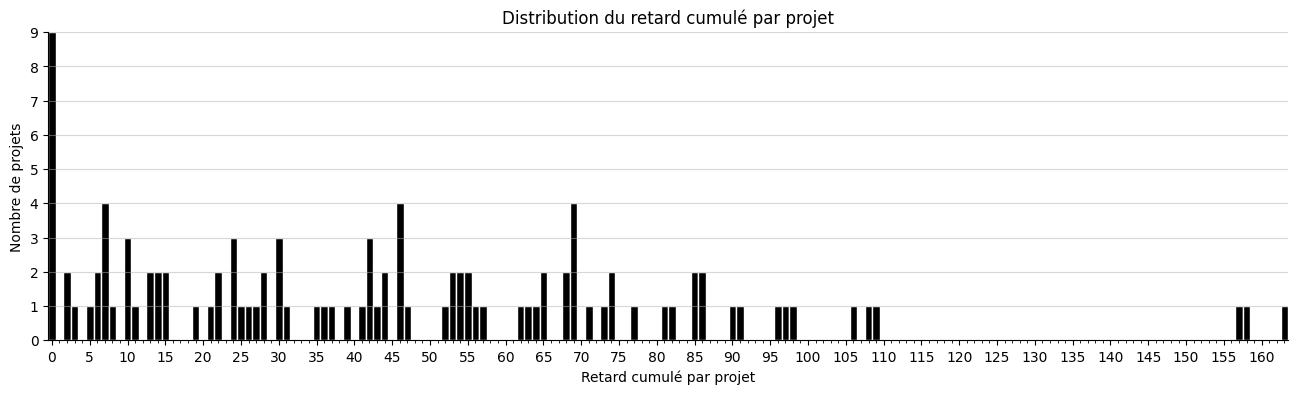

In [27]:
bins = np.arange(delay_min, delay_max + 2) - 0.5 # 1 bin = 1 value
ax = df_project["Delay"].plot.hist(bins=bins, color="black", edgecolor="white", figsize=(16,4))
plt.title("Distribution du retard cumulé par projet")
plt.ylabel("Nombre de projets")
plt.xlabel("Retard cumulé par projet")
plt.xlim(delay_min - 0.5, delay_max + 0.5)
plt.xticks(range(0,delay_max+1,5))
plt.xticks(range(0,delay_max+1), minor=True)
plt.ylim(0, 9)
plt.yticks(range(0,count_max+1))
plt.grid(axis="y", alpha=.5)
ax.spines["top"   ].set_visible(False)
ax.spines["right" ].set_visible(False)
plt.show()

## Préparation des données pour SciKit Learn

In [28]:
# Sélection des variables quantitatives
df_data = df_merge[["Planned_Duration","Planned_Cost","Planned_Deliverables","Actual_Duration","Actual_Cost","Actual_Deliverables"]]
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Planned_Duration      520 non-null    int64
 1   Planned_Cost          520 non-null    int64
 2   Planned_Deliverables  520 non-null    int64
 3   Actual_Duration       520 non-null    int64
 4   Actual_Cost           520 non-null    int64
 5   Actual_Deliverables   520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB


In [29]:
# Transformation de Project Type en matrice binaire
for project_type in sorted(pd.unique(df_merge["Project Type"])):
    df_data[f"Projet {project_type.split()[0]}"] = (df_merge["Project Type"] == project_type).astype(int)
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Planned_Duration      520 non-null    int64
 1   Planned_Cost          520 non-null    int64
 2   Planned_Deliverables  520 non-null    int64
 3   Actual_Duration       520 non-null    int64
 4   Actual_Cost           520 non-null    int64
 5   Actual_Deliverables   520 non-null    int64
 6   Projet IT             520 non-null    int64
 7   Projet Marketing      520 non-null    int64
dtypes: int64(8)
memory usage: 32.6 KB


In [30]:
# Transformation de Phase en matrice binaire
for phase in sorted(pd.unique(df_merge["Phase"])):
    df_data[phase[:7]] = (df_merge["Phase"] == phase).astype(int)
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Planned_Duration      520 non-null    int64
 1   Planned_Cost          520 non-null    int64
 2   Planned_Deliverables  520 non-null    int64
 3   Actual_Duration       520 non-null    int64
 4   Actual_Cost           520 non-null    int64
 5   Actual_Deliverables   520 non-null    int64
 6   Projet IT             520 non-null    int64
 7   Projet Marketing      520 non-null    int64
 8   Phase 1               520 non-null    int64
 9   Phase 2               520 non-null    int64
 10  Phase 3               520 non-null    int64
 11  Phase 4               520 non-null    int64
 12  Phase A               520 non-null    int64
 13  Phase B               520 non-null    int64
 14  Phase C               520 non-null    int64
 15  Phase D               520 non-null    int64
 16  Phase E            

In [31]:
# Start_Date est une variable temporelle : transformation en cycle de mois
df_data[f"Start_Month_cos"] = df_merge["Start_Month"].map(lambda month:np.cos(2*np.pi*(month-1)/12))
df_data[f"Start_Month_sin"] = df_merge["Start_Month"].map(lambda month:np.sin(2*np.pi*(month-1)/12))
df_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Planned_Duration      520 non-null    int64  
 1   Planned_Cost          520 non-null    int64  
 2   Planned_Deliverables  520 non-null    int64  
 3   Actual_Duration       520 non-null    int64  
 4   Actual_Cost           520 non-null    int64  
 5   Actual_Deliverables   520 non-null    int64  
 6   Projet IT             520 non-null    int64  
 7   Projet Marketing      520 non-null    int64  
 8   Phase 1               520 non-null    int64  
 9   Phase 2               520 non-null    int64  
 10  Phase 3               520 non-null    int64  
 11  Phase 4               520 non-null    int64  
 12  Phase A               520 non-null    int64  
 13  Phase B               520 non-null    int64  
 14  Phase C               520 non-null    int64  
 15  Phase D               520 non-null

In [32]:
df_month_cos_sin = pd.concat([ df_merge[["Start_Month"]], df_data[["Start_Month_cos","Start_Month_sin"]] ], axis=1)
df_month_cos_sin = df_month_cos_sin.drop_duplicates().sort_values("Start_Month").reset_index(drop=True)
df_month_cos_sin

,Start_Month,Start_Month_cos,Start_Month_sin
0,1,1.000000e+00,0.000000e+00
1,2,8.660254e-01,5.000000e-01
2,3,5.000000e-01,8.660254e-01
3,4,6.123234e-17,1.000000e+00
4,5,-5.000000e-01,8.660254e-01
5,6,-8.660254e-01,5.000000e-01
6,7,-1.000000e+00,1.224647e-16
7,8,-8.660254e-01,-5.000000e-01
8,9,-5.000000e-01,-8.660254e-01
9,10,-1.836970e-16,-1.000000e+00


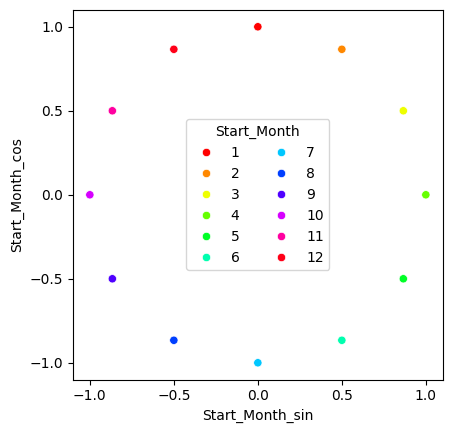

In [33]:
ax = sns.scatterplot(
    df_month_cos_sin, x="Start_Month_sin", y="Start_Month_cos",
    hue="Start_Month", palette="hsv", legend="full",
)
ax.set_aspect("equal", adjustable="box")
plt.xticks(np.linspace(-1,1,5))
plt.yticks(np.linspace(-1,1,5))
plt.legend(title="Start_Month", ncols=2)
plt.show()

In [34]:
df_data.to_csv("data/scikit-learn-ready.csv")

## SciKit Learn

In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

In [36]:
df_X = df_data[[
    "Planned_Duration", "Planned_Cost", "Planned_Deliverables",
    "Projet IT", "Projet Marketing",
    "Phase 1", "Phase 2", "Phase 3", "Phase 4",
    "Phase A", "Phase B", "Phase C", "Phase D", "Phase E", "Phase F",
    "Start_Month_cos", "Start_Month_sin",
]]
df_X.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Planned_Duration      520 non-null    int64  
 1   Planned_Cost          520 non-null    int64  
 2   Planned_Deliverables  520 non-null    int64  
 3   Projet IT             520 non-null    int64  
 4   Projet Marketing      520 non-null    int64  
 5   Phase 1               520 non-null    int64  
 6   Phase 2               520 non-null    int64  
 7   Phase 3               520 non-null    int64  
 8   Phase 4               520 non-null    int64  
 9   Phase A               520 non-null    int64  
 10  Phase B               520 non-null    int64  
 11  Phase C               520 non-null    int64  
 12  Phase D               520 non-null    int64  
 13  Phase E               520 non-null    int64  
 14  Phase F               520 non-null    int64  
 15  Start_Month_cos       520 non-null

In [37]:
df_y = df_data[[ "Actual_Duration", "Actual_Cost", "Actual_Deliverables" ]]
df_y.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Actual_Duration      520 non-null    int64
 1   Actual_Cost          520 non-null    int64
 2   Actual_Deliverables  520 non-null    int64
dtypes: int64(3)
memory usage: 12.3 KB


In [38]:
random_state = np.random.RandomState()

In [39]:
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.20, random_state=random_state)
print(f"{len(X_train)} lignes pour entraînement, {len(X_test)} lignes pour test")

416 lignes pour entraînement, 104 lignes pour test


In [40]:
dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [41]:
dummy_regressor.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [42]:
y_predict_train = dummy_regressor.predict(X_train)
y_predict_test  = dummy_regressor.predict(X_test )

r2_score_train = dummy_regressor.score(X_train, y_train)
r2_score_test  = dummy_regressor.score(X_test , y_test )

mse  = mean_squared_error (y_test, y_predict_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_predict_test)

print("DummyRegressor (mean)")
print(f"R² score (train): {r2_score_train:.3f}")
print(f"R² score  (test): {r2_score_test :.3f}")
print(f"MSE  (test): { mse:.3f}")
print(f"RMSE (test): {rmse:.3f}")
print(f"MAE  (test): { mae:.3f}")

DummyRegressor (mean)
R² score (train): -0.000
R² score  (test): -0.013
MSE  (test): 11442541411.863
RMSE (test): 106969.815
MAE  (test): 43220.667


In [43]:
linear_regression = LinearRegression()
linear_regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_predict_train = linear_regression.predict(X_train)
y_predict_test  = linear_regression.predict(X_test )

r2_score_train = linear_regression.score(X_train, y_train)
r2_score_test  = linear_regression.score(X_test , y_test )

mse  = mean_squared_error (y_test, y_predict_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_predict_test)

print("LinearRegression (Ordinary Least Squares)")
print(f"R² score (train): {r2_score_train:.3f}")
print(f"R² score  (test): {r2_score_test :.3f}")
print(f"MSE  (test): { mse:.3f}")
print(f"RMSE (test): {rmse:.3f}")
print(f"MAE  (test): { mae:.3f}")

LinearRegression (Ordinary Least Squares)
R² score (train): 0.829
R² score  (test): 0.802
MSE  (test): 197287532.511
RMSE (test): 14045.908
MAE  (test): 4723.610


In [46]:
df_coef = pd.DataFrame(linear_regression.coef_, index=df_y.columns, columns=df_X.columns)
df_coef

,Planned_Duration,Planned_Cost,Planned_Deliverables,Projet IT,Projet Marketing,Phase 1,Phase 2,Phase 3,Phase 4,Phase A,Phase B,Phase C,Phase D,Phase E,Phase F,Start_Month_cos,Start_Month_sin
Actual_Duration,0.622808,1.646667e-05,0.538653,2.996807,-2.996807,1.126299,-0.762398,0.740511,-4.101219,-5.739775,1.595049,0.193555,4.682398,2.201610,0.063971,-0.147776,0.640230
Actual_Cost,-41.655888,1.019788e+00,-87.955535,-6565.807534,6565.807534,-8617.747711,-6012.590100,2711.142265,18485.003079,-879.968995,2001.729296,1811.202265,14190.749731,-24442.156667,752.636836,65.400521,65.292872
Actual_Deliverables,-0.002628,-1.732529e-07,0.890709,-0.420113,0.420113,0.155839,-0.098371,0.136113,0.226532,0.056232,-0.143814,-0.411745,-0.287050,0.136447,0.229817,0.141258,-0.050859


In [47]:
df_intercept = pd.DataFrame(linear_regression.intercept_, index=df_y.columns, columns=["intercept"])
df_intercept

,intercept
Actual_Duration,12.577925
Actual_Cost,12163.967162
Actual_Deliverables,0.482833


In [48]:
for y in df_y.columns:
    print(df_intercept.loc[y])
    print()
    print(df_coef.loc[y].T.sort_values(ascending=False))
    print()

intercept    12.577925
Name: Actual_Duration, dtype: float64

Phase D                 4.682398
Projet IT               2.996807
Phase E                 2.201610
Phase B                 1.595049
Phase 1                 1.126299
Phase 3                 0.740511
Start_Month_sin         0.640230
Planned_Duration        0.622808
Planned_Deliverables    0.538653
Phase C                 0.193555
Phase F                 0.063971
Planned_Cost            0.000016
Start_Month_cos        -0.147776
Phase 2                -0.762398
Projet Marketing       -2.996807
Phase 4                -4.101219
Phase A                -5.739775
Name: Actual_Duration, dtype: float64

intercept    12163.967162
Name: Actual_Cost, dtype: float64

Phase 4                 18485.003079
Phase D                 14190.749731
Projet Marketing         6565.807534
Phase 3                  2711.142265
Phase B                  2001.729296
Phase C                  1811.202265
Phase F                   752.636836
Start_Month_cos   